# Amazon E-Commerce Product Data Analysis using Python

### Project Overview
This project focuses on analyzing Amazon e-commerce product data using Python.
The analysis includes data loading, data cleaning, exploratory data analysis (EDA),
data visualization, pricing analysis, product ratings, discounts, customer reviews,
and category-wise analysis.

The objective of this project is to identify important patterns in product pricing,
discounts, ratings, customer engagement, and product categories to generate
meaningful business insights.

In [4]:
pip install pandas numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [23]:
df = pd.read_csv("Amazon_Ecommerce_Products_Raw.csv")

df.head()

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,rating_weighted,category_1,category_2,rating_score,difference_price,neg,neu,pos,compound
0,B00O24PUO6,Orpat OEH-1260 2000-Watt Fan Heater (Grey),1464.0,1650.0,0.11,4.1,14120.0,57892.0,Home & Kitchen,"Heating, Cooling & Air Quality",Satisfied,186.0,0.108,0.576,0.316,0.9801
1,B00SMFPJG0,"Kent Gold, Optima, Gold+ Spare Kit",649.0,670.0,0.03,4.1,7786.0,31922.6,Home & Kitchen,Kitchen & Home Appliances,Satisfied,21.0,0.031,0.520,0.449,0.9850
2,B07J2BQZD6,Kuber Industries Nylon Mesh Laundry Basket|Stu...,199.0,399.0,0.50,3.7,7945.0,29396.5,Home & Kitchen,Home Storage & Organization,Neutral,200.0,0.090,0.520,0.390,0.9783
3,B0B2CZTCL2,Wipro Vesta 1.8 litre Cool touch electric Kett...,1299.0,1999.0,0.35,3.8,311.0,1181.8,Home & Kitchen,Kitchen & Home Appliances,Neutral,700.0,0.159,0.611,0.230,0.9555
4,B00J4YG0PC,"Classmate Long Notebook - 140 Pages, Single Li...",561.0,720.0,0.22,4.4,3182.0,14000.8,Office Products,Office Paper Products,Satisfied,159.0,0.070,0.335,0.595,0.9972


In [38]:
df.shape

(1259, 16)

In [39]:
df.columns

Index(['product_id', 'product_name', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'rating_weighted',
       'category_1', 'category_2', 'rating_score', 'difference_price', 'neg',
       'neu', 'pos', 'compound'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 0 to 1496
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1259 non-null   object 
 1   product_name         1259 non-null   object 
 2   discounted_price     1259 non-null   float64
 3   actual_price         1259 non-null   float64
 4   discount_percentage  1259 non-null   float64
 5   rating               1259 non-null   float64
 6   rating_count         1259 non-null   float64
 7   rating_weighted      1259 non-null   float64
 8   category_1           1259 non-null   object 
 9   category_2           1259 non-null   object 
 10  rating_score         1259 non-null   object 
 11  difference_price     1259 non-null   float64
 12  neg                  1259 non-null   float64
 13  neu                  1259 non-null   float64
 14  pos                  1259 non-null   float64
 15  compound             1259 non-null   float6

In [41]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,rating_weighted,difference_price,neg,neu,pos,compound
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000
mean,3239.284456,5663.568133,0.472343,4.090866,18522.129468,7.715862e+04,2424.283678,0.050768,0.571305,0.377925,0.968022
std,6999.401218,11073.485053,0.218278,0.293253,44625.878167,1.882425e+05,4763.747760,0.044545,0.105416,0.117946,0.174277
min,39.000000,39.000000,0.000000,2.000000,2.000000,4.000000e+00,0.000000,0.000000,0.190000,0.000000,-0.928800
25%,349.000000,899.000000,0.310000,3.900000,1168.000000,4.625600e+03,393.500000,0.021000,0.504500,0.291000,0.987900
50%,889.000000,1790.000000,0.490000,4.100000,4959.000000,2.039920e+04,811.000000,0.044000,0.576000,0.373000,0.993500
75%,2189.000000,4789.500000,0.630000,4.300000,17161.500000,6.844955e+04,2000.500000,0.069500,0.646000,0.452500,0.996300
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000,1.878681e+06,61910.000000,0.512000,0.835000,0.767000,0.999800


## Check Missing Values

In [42]:
df.isnull().sum()

product_id             0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
rating_weighted        0
category_1             0
category_2             0
rating_score           0
difference_price       0
neg                    0
neu                    0
pos                    0
compound               0
dtype: int64

## Check duplicate values

In [43]:
df.duplicated().sum()

np.int64(0)

## Remove duplicate values

In [44]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

##  Remove rows missing important information

In [45]:
df = df.dropna(subset=[
    'product_name',
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count',
    'category_1',
    'category_2'
])

## Check missing values after cleaning

In [57]:
df.isnull().sum()

product_id             0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
rating_weighted        0
category_1             0
category_2             0
rating_score           0
difference_price       0
neg                    0
neu                    0
pos                    0
compound               0
dtype: int64

## Check Data Types

In [55]:
df.dtypes

product_id              object
product_name            object
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
rating_weighted        float64
category_1              object
category_2              object
rating_score            object
difference_price       float64
neg                    float64
neu                    float64
pos                    float64
compound               float64
dtype: object

## Remove Unnecessary Columns

In [58]:
df = df.drop(columns=[
    'rating_weighted',
    'neg',
    'neu',
    'pos',
    'compound'
])

In [59]:
df.columns

Index(['product_id', 'product_name', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'category_1',
       'category_2', 'rating_score', 'difference_price'],
      dtype='object')

## Final Cleaning Verification

In [62]:
print("Rows and Columns:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Rows and Columns: (1259, 11)

Missing Values:
product_id             0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
category_1             0
category_2             0
rating_score           0
difference_price       0
dtype: int64

Duplicate Rows:
0

Data Types:
product_id              object
product_name            object
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
category_1              object
category_2              object
rating_score            object
difference_price       float64
dtype: object


In [63]:
df.head()

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,category_1,category_2,rating_score,difference_price
0,B00O24PUO6,Orpat OEH-1260 2000-Watt Fan Heater (Grey),1464.0,1650.0,0.11,4.1,14120.0,Home & Kitchen,"Heating, Cooling & Air Quality",Satisfied,186.0
1,B00SMFPJG0,"Kent Gold, Optima, Gold+ Spare Kit",649.0,670.0,0.03,4.1,7786.0,Home & Kitchen,Kitchen & Home Appliances,Satisfied,21.0
2,B07J2BQZD6,Kuber Industries Nylon Mesh Laundry Basket|Stu...,199.0,399.0,0.50,3.7,7945.0,Home & Kitchen,Home Storage & Organization,Neutral,200.0
3,B0B2CZTCL2,Wipro Vesta 1.8 litre Cool touch electric Kett...,1299.0,1999.0,0.35,3.8,311.0,Home & Kitchen,Kitchen & Home Appliances,Neutral,700.0
4,B00J4YG0PC,"Classmate Long Notebook - 140 Pages, Single Li...",561.0,720.0,0.22,4.4,3182.0,Office Products,Office Paper Products,Satisfied,159.0


## Save the Cleaned Dataset

In [67]:
df.to_csv("Amazon_Ecommerce_Products_Cleaned.csv", index=False)

## Final Dataset Shape

In [69]:
df.shape

(1259, 11)

# Exploratory Data Analysis (EDA)

## Statistical Summary

The describe() function provides summary statistics of numerical columns,
including count, mean, minimum, maximum, and standard deviation.

In [108]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,difference_price
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000
mean,3239.284456,5663.568133,4723.431295,4.090866,18522.129468,2424.283678
std,6999.401218,11073.485053,2182.780344,0.293253,44625.878167,4763.747760
min,39.000000,39.000000,0.000000,2.000000,2.000000,0.000000
25%,349.000000,899.000000,3100.000000,3.900000,1168.000000,393.500000
50%,889.000000,1790.000000,4900.000000,4.100000,4959.000000,811.000000
75%,2189.000000,4789.500000,6300.000000,4.300000,17161.500000,2000.500000
max,77990.000000,139900.000000,9400.000000,5.000000,426973.000000,61910.000000


## Total Number of Products

In [71]:
total_products = df['product_id'].nunique()

print("Total Number of Products:", total_products)

Total Number of Products: 1230


## Product Categories
This step displays the number of products available in each main category.

In [109]:
df['category_1'].value_counts()

category_1
Electronics                462
Home & Kitchen             410
Computers & Accessories    353
Office Products             27
Musical Instruments          2
Home Improvement             2
Toys & Games                 1
Health & PersonalCare        1
Car & Motorbike              1
Name: count, dtype: int64

In [110]:
#TOP 5 Categories
df['category_1'].value_counts().head(5)

category_1
Electronics                462
Home & Kitchen             410
Computers & Accessories    353
Office Products             27
Musical Instruments          2
Name: count, dtype: int64

## Average Product Rating

This analysis calculates the average customer rating of products in the dataset.

In [113]:
df['rating'].mean()

np.float64(4.090865766481334)

In [114]:
print("Average Product Rating:", round(df['rating'].mean(), 2))

Average Product Rating: 4.09


### Business Insight

The average product rating provides an overall indication of customer
satisfaction across the products in the dataset.

## Top 10 Product Categories

This bar chart shows the top 10 main product categories with the highest
number of products available in the dataset.

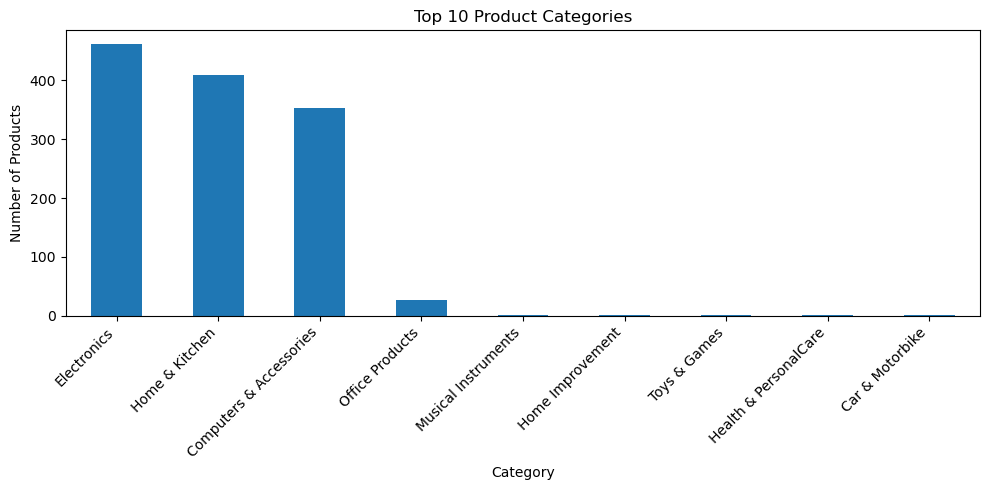

In [115]:
top_categories = df['category_1'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_categories.plot(kind='bar')

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Business Insight

The chart shows that product listings are concentrated in a few major categories.
These categories have greater product variety within the dataset.

## Product Rating Distribution

This histogram shows how product ratings are distributed across the dataset.

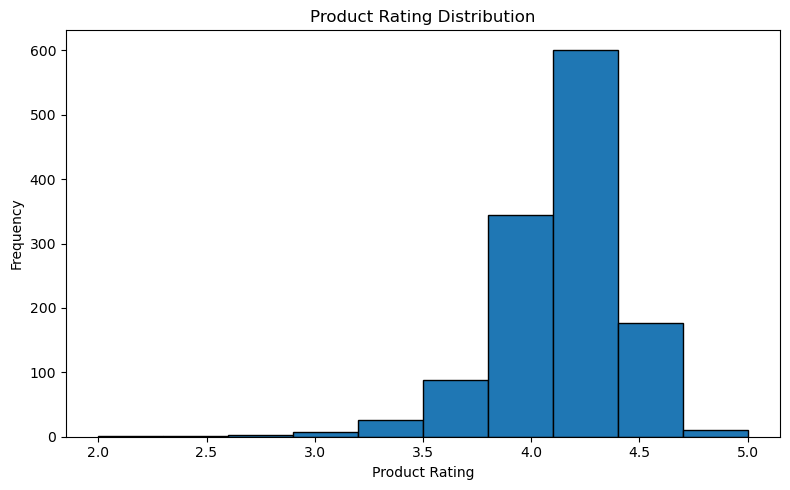

In [116]:
plt.figure(figsize=(8,5))

plt.hist(
    df['rating'],
    bins=10,
    edgecolor='black'
)

plt.title("Product Rating Distribution")
plt.xlabel("Product Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Business Insight

Most products are concentrated around the higher rating range,
indicating generally positive customer feedback.

## Product Rating Box Plot

This box plot shows the distribution of product ratings and helps identify
the median, spread, and unusual rating values in the dataset.

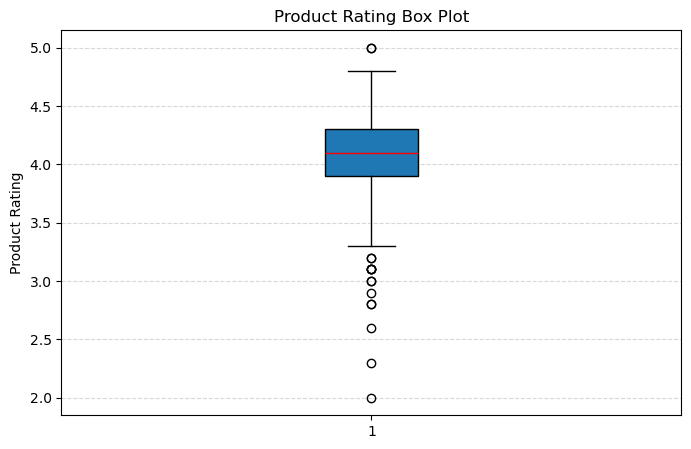

In [136]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['rating'],
    patch_artist=True,
    medianprops=dict(color='red')
)

plt.title("Product Rating Box Plot")
plt.ylabel("Product Rating")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Business Insight

Most product ratings are concentrated within a relatively narrow range.
The box plot also helps identify unusually low or high rating values.

## Top 10 Most Reviewed Products

This chart shows the products with the highest number of customer ratings.
It helps identify products with strong customer engagement.

In [121]:
top_reviewed = df.sort_values(
    by='rating_count',
    ascending=False
).head(10)

top_reviewed[
    ['product_name', 'rating', 'rating_count']
]

,product_name,rating,rating_count
85,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0
558,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0
672,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0
658,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426972.0
403,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
36,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
338,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0
1114,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",4.1,313836.0
892,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",4.1,313836.0
1438,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",4.1,313832.0


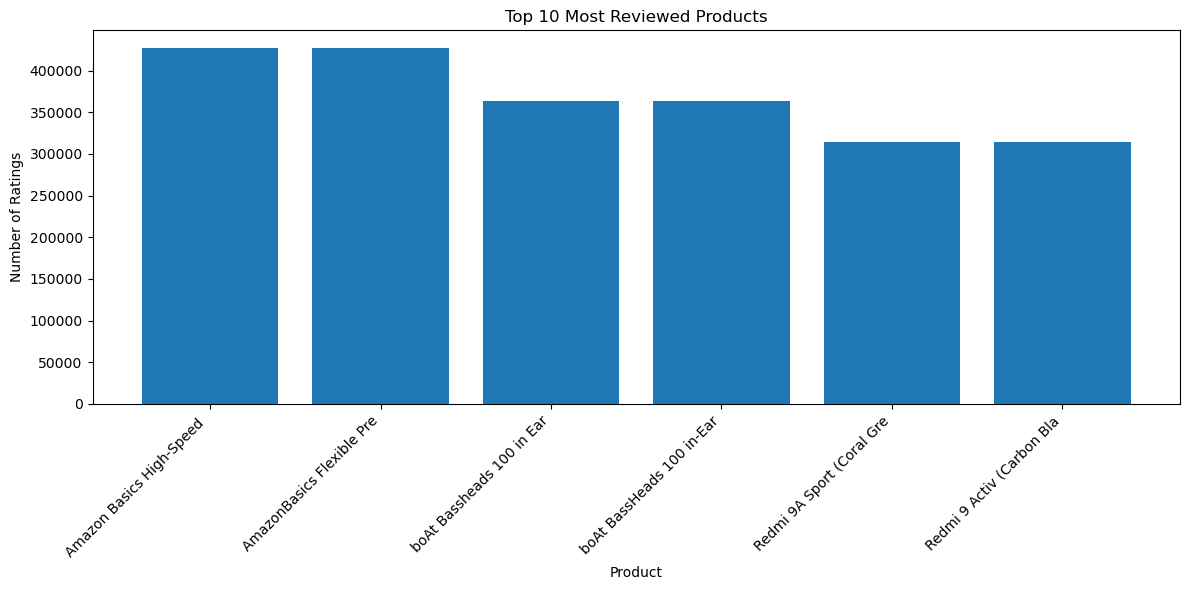

In [122]:
top_reviewed_chart = top_reviewed.copy()

top_reviewed_chart['short_name'] = (
    top_reviewed_chart['product_name'].str[:25]
)

plt.figure(figsize=(12,6))

plt.bar(
    top_reviewed_chart['short_name'],
    top_reviewed_chart['rating_count']
)

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Product")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Business Insight

A small number of products receive a large number of customer ratings.
These products show higher customer engagement and visibility.

## Category-wise Product Share

This pie chart represents the percentage distribution of products across
the top product categories in the Amazon dataset.

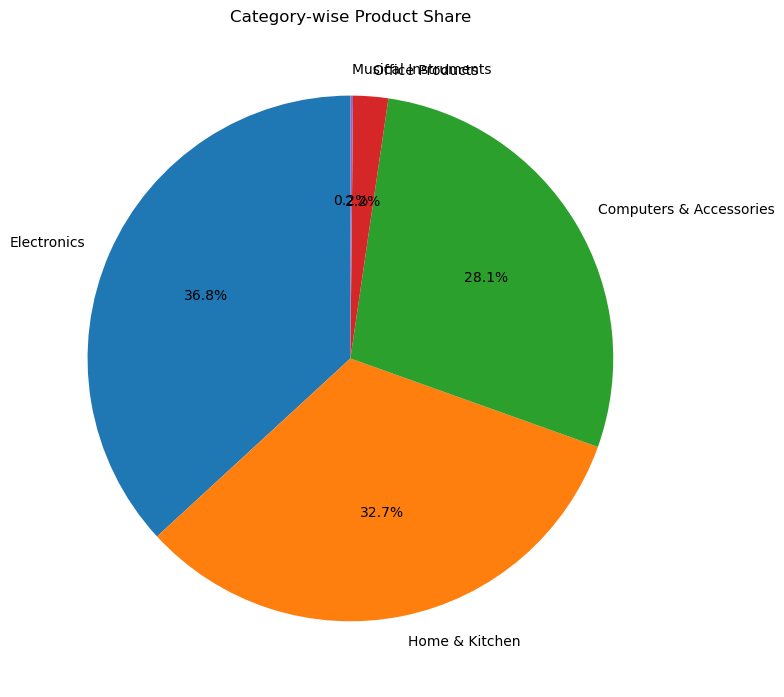

In [123]:
top_categories = df['category_1'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_categories,
    labels=top_categories.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Category-wise Product Share")

plt.tight_layout()
plt.show()

### Business Insight

The pie chart shows the percentage share of products across the major
categories. A few categories contribute a larger share of the product
catalog, indicating greater product availability in those segments.

## Selling Price Distribution

This histogram shows the distribution of discounted selling prices
across Amazon products.

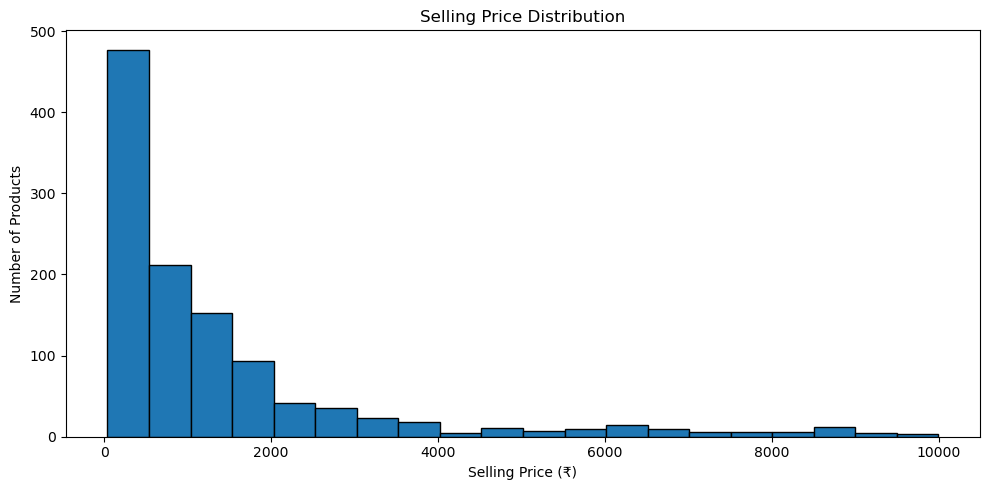

In [124]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df['discounted_price'] < 10000]['discounted_price'],
    bins=20,
    edgecolor='black'
)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

### Business Insight

Most products are available within the low and medium price range.
A smaller number of premium products have much higher prices.

## Top 10 Sub-Categories

This bar chart shows the top 10 sub-categories with the highest number
of products.

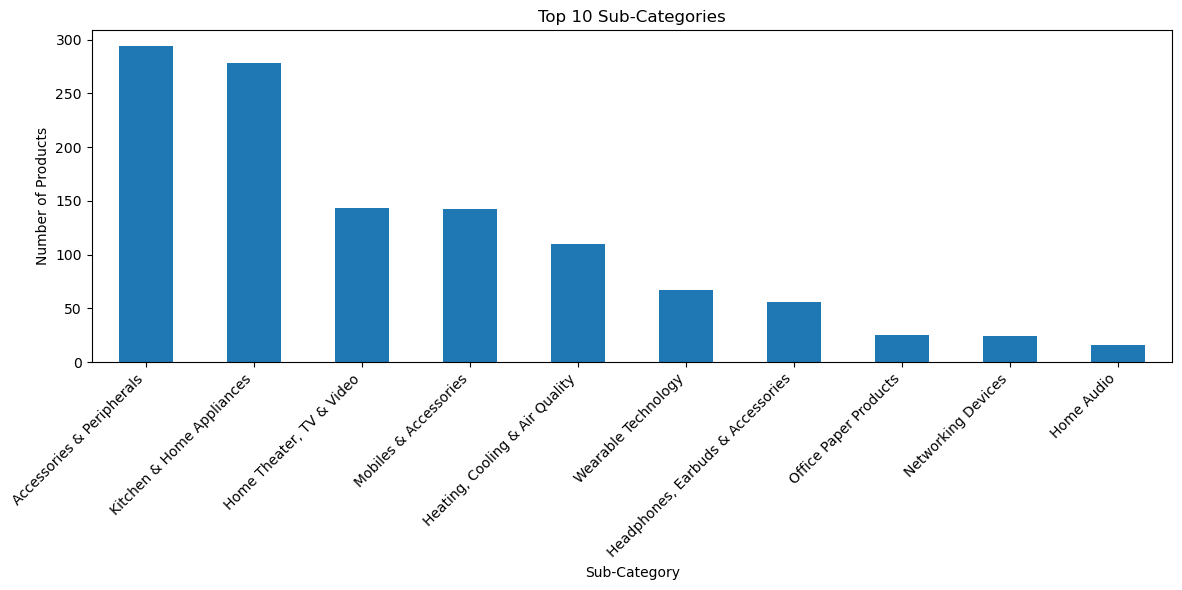

In [125]:
top_subcategories = df['category_2'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_subcategories.plot(kind='bar')

plt.title("Top 10 Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Business Insight

A few sub-categories contain a large number of products.
These represent the most active product segments in the dataset.

## Check Discount Percentage
Before creating the graph, very important: check your values.

In [128]:
df['discount_percentage'].head()

0    110000.0
1     30000.0
2    500000.0
3    350000.0
4    220000.0
Name: discount_percentage, dtype: float64

## convert them to percentages

In [129]:
df['discount_percentage'] = df['discount_percentage'] * 100

In [130]:
df['discount_percentage'].head(10)

0    11000000.0
1     3000000.0
2    50000000.0
3    35000000.0
4    22000000.0
5    76000000.0
6    14000000.0
7    65000000.0
8    79000000.0
9    83000000.0
Name: discount_percentage, dtype: float64

## Discount Percentage Distribution

This histogram shows the distribution of discounts offered across Amazon
products and helps understand the platform's promotional pricing pattern.

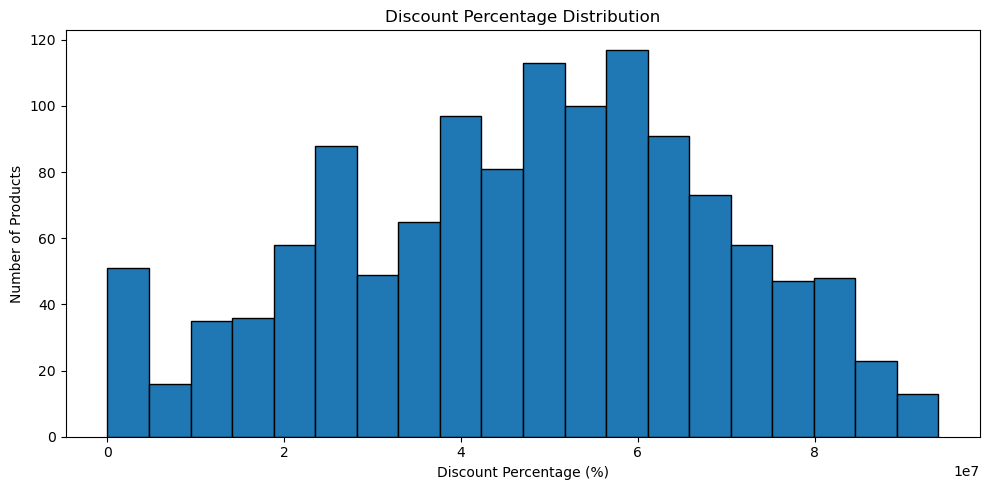

In [133]:
plt.figure(figsize=(10,5))

plt.hist(
    df['discount_percentage'],
    bins=20,
    edgecolor='black'
)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

### Business Insight

Discount levels vary across products, showing different promotional
pricing strategies across the Amazon product catalog.

# Findings

- Most products are concentrated in a few major Amazon categories.
- Product ratings are generally on the higher side, indicating positive customer feedback.
- Some products receive a very large number of customer ratings, showing strong customer engagement.
- Product prices are mostly concentrated in the low and medium price ranges, while a few products are highly priced.
- Product discounts vary across the dataset, indicating different promotional pricing strategies.
- A few sub-categories contain a large number of products compared to others.
- Category-wise product share shows that some categories contribute a larger portion of the product catalog.

# Conclusion

This project analyzed Amazon e-commerce product data using Python. The analysis
included data loading, data cleaning, exploratory data analysis, and data
visualization.

The project helped identify important patterns related to product categories,
pricing, discounts, customer ratings, and customer engagement. The visualizations
provided useful business insights into the Amazon product catalog.

Overall, this project demonstrates how Python and data analysis techniques can
be used to clean raw e-commerce data, identify trends, and generate meaningful
business insights for better decision-making.